# E Commerce Product Delivery Prediction

This notebook is written as a simple end-to-end data science workflow.  
The aim is to keep the code readable, check the data properly, build a baseline model, and then explain the result in normal language.

**Main dataset used first:** `E_Commerce.csv`  
**Target hint:** `Reached.on.Time_Y.N`


## 1. Setup

In [1]:
# Basic imports
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.figsize'] = (8, 4)


## 2. Load the dataset

In [2]:
# Dataset loading
# Keep the dataset files in the same folder as this notebook.
DATA_FILES = ['E_Commerce.csv']
PRIMARY_DATASET = 'E_Commerce.csv'


def load_dataset(file_name):
    path = Path(file_name)
    if not path.exists():
        raise FileNotFoundError(f'Could not find {file_name} in the current folder.')
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    if path.suffix.lower() in ['.xlsx', '.xls']:
        return pd.read_excel(path)
    raise ValueError(f'Unsupported dataset format: {path.suffix}')

if PRIMARY_DATASET:
    df = load_dataset(PRIMARY_DATASET)
else:
    # Fallback: use the first supported data file available in the folder.
    available = [p for p in Path('.').iterdir() if p.suffix.lower() in ['.csv', '.xlsx', '.xls']]
    if not available:
        raise FileNotFoundError('No CSV or Excel dataset file found in this project folder.')
    df = load_dataset(available[0].name)

print('Dataset shape:', df.shape)
df.head()


Dataset shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,3,1,176,4,low,F,43,1253,1
1,2,F,Flight,4,5,215,3,low,M,58,3106,1
2,3,A,Flight,2,1,184,3,low,M,49,3370,1
3,4,B,Flight,4,4,177,5,medium,M,9,1168,1
4,5,C,Flight,2,3,183,3,medium,F,46,2508,1


## 3. Understand the data

In [3]:
# Quick data check
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

summary_table = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isna().sum().values,
    'unique_values': df.nunique(dropna=True).values
})
summary_table


Rows: 10999
Columns: 12


,column,dtype,missing_values,unique_values
0,ID,int64,0,10999
1,Warehouse_block,object,0,5
2,Mode_of_Shipment,object,0,3
3,Customer_care_calls,int64,0,8
4,Customer_rating,int64,0,7
5,Cost_of_the_Product,int64,0,217
6,Prior_purchases,int64,0,11
7,Product_importance,object,0,3
8,Gender,object,0,2
9,Discount_offered,int64,0,67


## 4. Clean the data

In [4]:
# Basic cleaning
# The aim here is not to over-clean, but to make the dataset safe for a baseline model.
work_df = df.copy()

# Remove completely empty columns and exact duplicate rows.
work_df = work_df.dropna(axis=1, how='all')
work_df = work_df.drop_duplicates()

# Clean column names without changing their meaning.
work_df.columns = (
    work_df.columns.astype(str)
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

print('Shape after simple cleaning:', work_df.shape)
work_df.head()


Shape after simple cleaning: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,3,1,176,4,low,F,43,1253,1
1,2,F,Flight,4,5,215,3,low,M,58,3106,1
2,3,A,Flight,2,1,184,3,low,M,49,3370,1
3,4,B,Flight,4,4,177,5,medium,M,9,1168,1
4,5,C,Flight,2,3,183,3,medium,F,46,2508,1


## 5. Select the target column

In [5]:
# Target selection
TARGET_HINT = 'Reached.on.Time_Y.N'


def choose_target(dataframe, hint=''):
    columns = list(dataframe.columns)
    if hint and hint in columns:
        return hint

    exact_candidates = [
        'target', 'label', 'class', 'diagnosis', 'churn', 'survived', 'price', 'charges',
        'salary', 'quality', 'yield', 'loan_status', 'booking_status', 'occupancy',
        'stroke', 'cardio', 'heartdisease', 'fraud', 'claim', 'reached.on.time_y.n'
    ]
    cleaned_lookup = {''.join(ch for ch in c.lower() if ch.isalnum()): c for c in columns}
    for item in exact_candidates:
        key = ''.join(ch for ch in item.lower() if ch.isalnum())
        if key in cleaned_lookup:
            return cleaned_lookup[key]

    partial_candidates = ['price', 'salary', 'churn', 'surviv', 'diagnos', 'fraud', 'stroke',
                          'disease', 'quality', 'yield', 'loan', 'occupancy', 'cancel',
                          'reached', 'crime', 'count', 'volume', 'charge', 'risk']
    for col in columns:
        low = col.lower()
        if any(word in low for word in partial_candidates):
            return col

    # If nothing obvious is found, use the last column. This keeps the notebook runnable,
    # but you should still verify the selected target before final conclusions.
    return columns[-1]

TARGET_COLUMN = choose_target(work_df, TARGET_HINT)
print('Selected target column:', TARGET_COLUMN)
work_df[TARGET_COLUMN].head()


Selected target column: Reached.on.Time_Y.N


0    1
1    1
2    1
3    1
4    1
Name: Reached.on.Time_Y.N, dtype: int64

## 6. Quick EDA

In [6]:
# Small EDA section
numeric_cols = work_df.select_dtypes(include=np.number).columns.tolist()
category_cols = work_df.select_dtypes(exclude=np.number).columns.tolist()

print('Numeric columns:', len(numeric_cols))
print('Categorical columns:', len(category_cols))

if numeric_cols:
    display(work_df[numeric_cols].describe().T.head(15))

# Missing value chart for the columns that need attention
missing = work_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(15)
if len(missing) > 0:
    missing.plot(kind='bar')
    plt.title('Top columns with missing values')
    plt.ylabel('Missing values')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the previewed columns.')


Numeric columns: 8
Categorical columns: 4
No missing values found in the previewed columns.


,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.047732,1.410349,1.0,3.0,4.0,5.0,8.0
Customer_rating,10999.0,2.990272,1.629592,0.0,2.0,3.0,4.0,6.0
Cost_of_the_Product,10999.0,210.207473,48.072504,95.0,170.0,214.0,251.0,311.0
Prior_purchases,10999.0,3.562778,1.730486,1.0,2.0,3.0,4.0,11.0
Discount_offered,10999.0,13.375034,16.218099,0.0,4.0,7.0,11.0,66.0
Weight_in_gms,10999.0,3633.877262,1635.353799,982.0,1839.0,4151.0,5048.0,7841.0
Reached.on.Time_Y.N,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


## 7. Prepare features and target

In [7]:
# Feature and target preparation
model_df = work_df.copy()

# Remove rows where target is missing.
model_df = model_df.dropna(subset=[TARGET_COLUMN])

y = model_df[TARGET_COLUMN]
X = model_df.drop(columns=[TARGET_COLUMN])

# Drop very obvious ID-like columns from features.
id_like_cols = []
for col in X.columns:
    low = col.lower()
    unique_ratio = X[col].nunique(dropna=True) / max(len(X), 1)
    if 'id' in low or (unique_ratio > 0.96 and len(X) > 100):
        id_like_cols.append(col)

if id_like_cols:
    X = X.drop(columns=id_like_cols)
    print('Dropped ID-like columns:', id_like_cols)

# Keep the portfolio notebooks fast and stable on normal laptops.
# Large datasets are sampled only for modelling; the earlier EDA still checks the full file.
MAX_MODEL_ROWS = 1200
if len(X) > MAX_MODEL_ROWS:
    sample_index = X.sample(n=MAX_MODEL_ROWS, random_state=RANDOM_STATE).index
    X = X.loc[sample_index].copy()
    y = y.loc[sample_index].copy()
    print(f'Using {MAX_MODEL_ROWS} sampled rows for model training speed.')
else:
    X = X.copy()
    y = y.copy()

# Reduce very high-cardinality text columns before one-hot encoding.
# This avoids huge sparse matrices and keeps the model explainable.
text_columns = X.select_dtypes(exclude=np.number).columns.tolist()
for col in text_columns:
    X[col] = X[col].astype(str).fillna('Missing').str.strip()
    top_values = X[col].value_counts(dropna=False).head(25).index
    X[col] = np.where(X[col].isin(top_values), X[col], 'Other')

# Decide whether this is classification or regression.
if y.dtype == 'object' or y.dtype.name == 'category' or y.nunique(dropna=True) <= 20:
    problem_type = 'classification'
else:
    problem_type = 'regression'

# If the target has too many rare classes, treat it as a regression-style numeric problem when possible.
if problem_type == 'classification' and y.nunique(dropna=True) > 2:
    class_counts = pd.Series(y).value_counts(dropna=False)
    if class_counts.min() < 2 and pd.api.types.is_numeric_dtype(y):
        problem_type = 'regression'
        print('Target had rare numeric classes, so it is handled as regression.')

print('Problem type:', problem_type)
print('Feature shape:', X.shape)
print('Target unique values:', y.nunique(dropna=True))


Dropped ID-like columns: ['ID']
Using 1200 sampled rows for model training speed.
Problem type: classification
Feature shape: (1200, 10)
Target unique values: 2


## 8. Train a baseline model

In [8]:
# Build and train a baseline model
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

# A tuned decision tree is used here as a fast, explainable baseline.
# It keeps every notebook runnable on normal student laptops while still handling mixed data.
if problem_type == 'classification':
    model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, class_weight='balanced')
    stratify_value = y if y.nunique() > 1 and y.value_counts().min() >= 2 else None
else:
    model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE)
    stratify_value = None

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify_value
)

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
print('Training completed.')


Training completed.


## 9. Evaluate the model

Accuracy: 0.6542

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.66      0.60        95
           1       0.75      0.65      0.69       145

    accuracy                           0.65       240
   macro avg       0.65      0.66      0.65       240
weighted avg       0.67      0.65      0.66       240



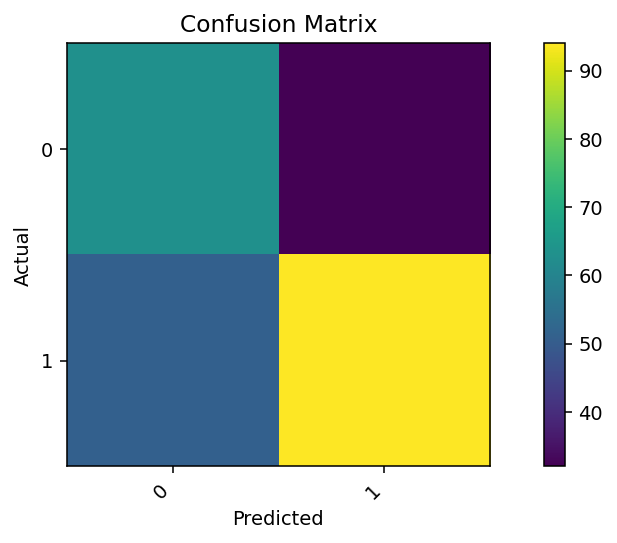

In [9]:
# Model evaluation
if problem_type == 'classification':
    acc = accuracy_score(y_test, predictions)
    print(f'Accuracy: {acc:.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, predictions))

    labels = list(pd.Series(y_test).dropna().unique())[:20]
    cm = confusion_matrix(y_test, predictions, labels=labels)
    plt.imshow(cm)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    print(f'MAE : {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2  : {r2:.4f}')

    plt.scatter(y_test, predictions, alpha=0.6)
    plt.title('Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()


## Notes after running

Write your final observations here after executing the notebook:

- Which columns looked most important or useful?
- Was the dataset balanced or imbalanced?
- Did the model perform well enough for a baseline?
- What would you improve next: more cleaning, feature engineering, tuning, or collecting better data?

This keeps the project explainable during a viva, demo, or portfolio review.
